# Energy Intensity Calculations



In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
import matplotlib.ticker as mticker
import seaborn as sns
import os

Typical Vessel Classes and Values


In [57]:
########### EVessel Correction Factor - from Gucwa Paper##########
Vessel_class = {
    'Container Ships' : 0.01,
    'LNG Carriers' : 0.39,
    'Product Tankers' : 0.56,
}

########## Capacity Utilization ##########
Capacity_utilization = {
    'Container Ships' : 0.8,
    'Bulk Carriers' : 0.7,
    'Oil Tankers' : 0.7,
}


cap = np.mean(list(Capacity_utilization.values()))  # Example capacity utilizatio


class VesselType:
    """
    Class representing typical freight capacity for international shipping vessels.
    
    Sources:
        - UNCTAD (2023), Review of Maritime Transport
        - IMO (2020), Fourth GHG Study
        - Clarksons Research (2023)
        - Alphaliner (2024)
    """

    def __init__(self, name, capacity_metric, typical_freight_t, max_freight_t):
        self.name = name
        self.capacity_metric = capacity_metric
        self.typical_freight_t = typical_freight_t
        self.max_freight_t = max_freight_t

    def __repr__(self):
        return (f"VesselType(name={self.name!r}, "
                f"metric={self.capacity_metric!r}, "
                f"typical={self.typical_freight_t}, "
                f"max={self.max_freight_t})")


# --- Define vessel dataset ----------------------------------------------------

vessels = {
    "Feeder Container": VesselType("Feeder Container", "1,000–3,000 TEU", (10_000, 40_000), 20_000),
    "Panamax Container": VesselType("Panamax Container", "4,000–5,000 TEU", (60_000, 80_000), 100_000),
    "Post-Panamax": VesselType("Post-Panamax Container", "8,000–14,000 TEU", (100_000, 180_000), 220_000),
    "Ultra Large Container": VesselType("ULCS", "18,000–24,000 TEU", (200_000, 250_000), 270_000),

    "Handysize Bulk": VesselType("Handysize Bulk Carrier", "—", (25_000, 40_000), 50_000),
    "Supramax": VesselType("Supramax/Ultramax Bulk Carrier", "—", (50_000, 65_000), 70_000),
    "Panamax Bulk": VesselType("Panamax Bulk Carrier", "—", (65_000, 80_000), 85_000),
    "Capesize": VesselType("Capesize Bulk Carrier", "—", (150_000, 180_000), 200_000),
    "VLOC": VesselType("Very Large Ore Carrier", "—", (250_000, 360_000), 400_000),

    "Aframax": VesselType("Aframax Tanker", "—", (80_000, 120_000), 130_000),
    "Suezmax": VesselType("Suezmax Tanker", "—", (120_000, 160_000), 200_000),
    "VLCC": VesselType("Very Large Crude Carrier", "—", (200_000, 300_000), 330_000),
    "ULCC": VesselType("Ultra Large Crude Carrier", "—", (350_000, 500_000), 550_000),

    "LNG": VesselType("LNG Carrier", "125,000–266,000 m³ LNG", (55_000, 120_000), 120_000),
    "RoRo": VesselType("Vehicle Carrier (Ro-Ro)", "4,000–6,500 CEU", (20_000, 40_000), 45_000),
    "General": VesselType("General Cargo Ship", "—", (5_000, 25_000), 30_000),
}

avg_freight = sum((sum(v.typical_freight_t) / 2) for v in vessels.values()) / len(vessels)/1000  # in 1000 t



# EI vs TKM relation from Gucwa

https://www.sciencedirect.com/science/article/pii/S1361920913000515?via%3Dihub 



In [67]:
########## Shipping Energy Intensity Model ##########
average_speed =  26  # Average speed km/h
class_i = 0       # Class value for observation i (e.g., categorical encoded as integer or dummy)
D_class = 0         # Coefficient for class_i
epsilon_i = 0     # Error term for observation i

def shipping_EI(cap,load,class_i,D_class, speed):
    Gamma = cap*load
    C = -1.051               # Intercept
    beta = -0.589              # Coefficient for log(Gamma)
    gamma = 1.416            # Coefficient for log(average_speed)   
    epsilon_i = 0     # Error term for observation i

    log_E_over_RTK_t = C + beta * sp.log(Gamma) + gamma * sp.log(speed) + D_class * class_i + epsilon_i
    # convert from log(E/RTK) back to normal scale
    E_over_RTK_t = sp.exp(log_E_over_RTK_t)
    return E_over_RTK_t, log_E_over_RTK_t

## Plotting


## Solve for Breyer

Backtrack Breyer Assumption for EI of 0.15 MJ/tkm


In [ ]:

EI_Breyer = 0.15  # MJ/tkm
EI_PICs_weighted = 2.06  # MJ/tkm
EI_PICs_unweighted = 5.3  # MJ/tkm
EI_PICs_avgfr_wprasad = 3.2 # MJ/tkm
load = sp.symbols('load')
PIC_speed = average_speed  # km/h
D_class_domestic = -0.5  # Coefficient for domestic shipping class


############ Solve for Breyer ############
EI_equation = shipping_EI(cap, load, 0, 0, average_speed)[1]
Breyer_equation= sp.Eq(EI_equation,EI_Breyer)
T_Breyer = sp.solve(Breyer_equation, load)
print("Load Factor for EI of 0.15 MJ/tkm: ", round(T_Breyer[0],2), "thousands of Tonnes")

########### Solve for PICs ############
T_Pics_weighted = sp.solve(sp.Eq(shipping_EI(cap, load, 0, 0, PIC_speed)[1],EI_PICs_weighted), load)
print("PIC Load Factor for EI of 2.06 MJ/tkm: ", round(T_Pics_weighted[0],2), "thousands of Tonnes")

########### Solve for PICs avg freight and Prasad ############
# including VEssel Class correction for domestic shipping
# and full load factor
T_Pics_avgfr_wprasad = sp.solve(sp.Eq(shipping_EI(1, load, 1, D_class_domestic, PIC_speed)[1],EI_PICs_avgfr_wprasad), load)
print("PIC Load Factor for EI of 3.2 MJ/tkm: ", round(T_Pics_avgfr_wprasad[0],2), "thousands of Tonnes")

########### Solve for PICs ############
T_Pics_unweighted = sp.solve(sp.Eq(shipping_EI(cap, load, 0, 0, PIC_speed)[1],EI_PICs_unweighted), load)
print("PIC Load Factor for EI of 5.3 MJ/tkm: ", round(T_Pics_unweighted[0],2), "thousands of Tonnes")

########### EI at avg freight international shipping ############
EI_avg_freight = shipping_EI(cap, avg_freight, 0, 0, average_speed)[1]
print("EI at avg international freight (",avg_freight, "thousands of tonnes): ", round(EI_avg_freight,2), "MJ/tkm")

########### EI at avg freight domestic shipping ############
EI_avg_dom_freight = shipping_EI(cap, 0.336, 0, 0, average_speed)[1]
print("EI at avg domestic freight (",0.336, "thousands of tonnes): ", round(EI_avg_dom_freight,2), "MJ/tkm")

Load Factor for EI of 0.15 MJ/tkm:  447.56 thousands of Tonnes
PIC Load Factor for EI of 2.06 MJ/tkm:  17.48 thousands of Tonnes
PIC Load Factor for EI of 3.2 MJ/tkm:  0.79 thousands of Tonnes
PIC Load Factor for EI of 5.3 MJ/tkm:  0.07 thousands of Tonnes
EI at avg international freight ( 133.75 thousands of tonnes):  0.86 MJ/tkm
EI at avg domestic freight ( 0.336 thousands of tonnes):  4.39 MJ/tkm


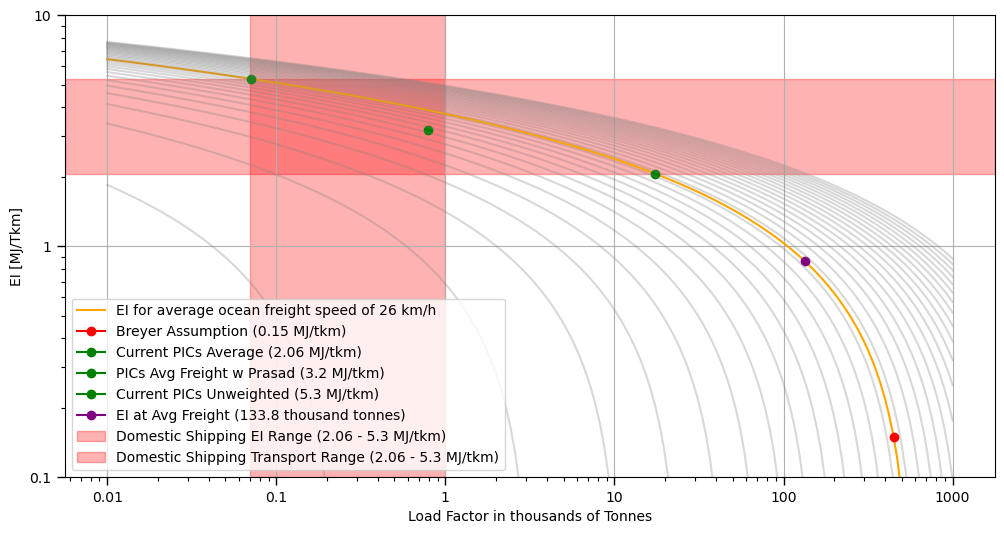

In [145]:
######################################## Plot graph 
# create a range for Gamma and compute the log(E/Rtk) for plotting (avoid log(0) with eps)
load_list = np.logspace(-2, 3, 200)  # 0.01 .. 100  # ensure positive
shipping_EI_numeric = sp.lambdify((load),shipping_EI(cap,load,class_i,D_class,average_speed),"numpy")

log_EI_vals = shipping_EI_numeric(load_list)  # get log(E/RTK) values for plotting
EI_Vals = shipping_EI_numeric(load_list)  # get E/RTK values for plotting

plt.figure(figsize=(12, 6))
#plt.plot(load_list, log_EI_vals)                   # <-- single line that plots the equation vs Gamma
plt.plot(load_list, EI_Vals[1], color='orange',label = 'EI for average ocean freight speed of 26 km/h')                   # <-- single line that plots the equation vs Gamma
# plt.axhline(y=EI_Breyer, color='r', linestyle='--',alpha = 0.5, label='Breyer Assumption (0.15 MJ/tkm)')
# #plt.axhline(y=EI_PICs_weighted, color='g', linestyle='--',alpha = 0.5, label='Current PICs Average (5.3 MJ/tkm)')
# plt.axhline(y=EI_avg_freight, color='b', linestyle='--',alpha = 0.5, label='EI at Avg Freight ({} thousand tonnes)'.format(round(avg_freight,1)))
# plt.axvline(x=T_Breyer[0], color='r',alpha = 0.5, linestyle='--')
# #plt.axvline(x=T_Pics_weighted[0], color='g',alpha = 0.5, linestyle='--')
# plt.axvline(x=avg_freight, color='b',alpha = 0.5, linestyle='--')
plt.plot(T_Breyer[0],EI_Breyer,color='r',marker = 'o',label='Breyer Assumption (0.15 MJ/tkm)')
plt.plot(T_Pics_weighted[0],EI_PICs_weighted,marker = 'o',color='g',label='Current PICs Average (2.06 MJ/tkm)')
plt.plot(T_Pics_avgfr_wprasad[0],EI_PICs_avgfr_wprasad,marker = 'o',color='g',label='PICs Avg Freight w Prasad (3.2 MJ/tkm)')
plt.plot(T_Pics_unweighted[0],EI_PICs_unweighted,marker = 'o',color='g',label='Current PICs Unweighted (5.3 MJ/tkm)')
plt.plot(avg_freight,EI_avg_freight,marker = 'o',color='purple',label='EI at Avg Freight ({} thousand tonnes)'.format(round(avg_freight,1)))
# ####### EI Range #######
plt.axhspan(2.06, 5.3, color='red', alpha=0.3, label='Domestic Shipping EI Range (2.06 - 5.3 MJ/tkm)')
plt.axvspan(0.07, 1, color='red', alpha=0.3, label='Domestic Shipping Transport Range (2.06 - 5.3 MJ/tkm)')

############# Speed Set up ################
speed = sp.symbols('speed')
f_num = sp.lambdify((load,speed),shipping_EI(cap,load,class_i,D_class,speed)[1],"numpy")

# --- 3. Create grid of values ---
speed_vals = np.linspace(1., 61., num =31) # speed from 0 to 40 km/h
X, Y = np.meshgrid(speed_vals, load_list)

# --- 4. Evaluate function on the grid ---
# lambdify expects (load, speed) so pass Y (loads) first, X (speeds) second
Z = f_num(Y, X)  # Z is a tuple: (E_over_RTK_t_array, log_E_over_RTK_t_array) with shape (len(load_list), len(speed_vals))

# --- 5. Plot EI vs Load for each speed in the background ---
# Use Z[0] (E_over_RTK_t) for plotting EI on the y-axis
for speed_idx in range(Z.shape[1]):
	plt.plot(load_list, Z[:, speed_idx], color='grey', alpha=0.3)  # plot EI vs load for each speed

####### 

plt.legend()
# Set log-log scale
plt.xscale('log')
plt.yscale('log')
ax = plt.gca()
## limit y axis
ax.set_ylim(0.1, 10)

# keep automatic ticks but force plain (non-exponential) formatting
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
# show more ticks on log-log axes: denser major ticks and visible minor ticks
ax.xaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=15))
ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(1,10), numticks=50))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.yaxis.set_major_locator(mticker.LogLocator(base=10.0, numticks=15))
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(1,10), numticks=50))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, pos: f"{y:g}"))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

# Make ticks more visible
ax.tick_params(axis='both', which='major', length=6, width=1)
ax.tick_params(axis='both', which='minor', length=3, width=0.8)

# Add labels and title
plt.xlabel('Load Factor in thousands of Tonnes')
plt.ylabel('EI [MJ/Tkm]')
plt.grid(True)
plt.show()
# ...existing code...


## Future Scenarios

In [153]:
# implement S-curve transition

def s_curve(x, x0, k,min_val, max_val):
    S = min_val + (max_val - min_val) * (1 / (1 + np.exp(-k * (x - x0))))
    return S

#x= plt.linespace(2020, 2050, 100)


# Retrofit Scenario till 2035

Domestic Vessels get gradually retrofitted with auxiliary sails, Flettner rotos and solar PVs which are estimated to reduce fuel consumption by 40% by 2035

“A sufficient range of known retrofit measures exists to assume that a 40 % overall emission reduction by 2030 is technically attainable… dependent on finance and capacity.” - Nuttal

40 % fuel/emission reduction by 2030 through retrofits and hybridisation of existing fleets. - PBSP

Saved retrofit scenario to data/retrofit_scenario_2022_2050.csv


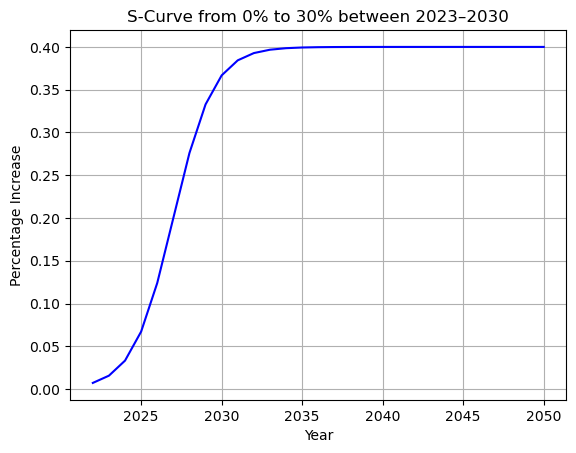

In [ ]:
#### years of interest
years = {2023,2025, 2030,2035,2040,2045,2050}
years_scurve = np.linspace(2023, 2030, 100)


retro_min_val = 0.0
retro_max_val = 0.4
x0_retro = 2027
k_retro = 0.8


# yearly series 2022..2050
years_yearly = np.arange(2022, 2051)
s_retro_yearly = s_curve(years_yearly, x0_retro, k_retro, retro_min_val, retro_max_val)

# enforce full adoption (40%) from 2030 onward
s_yearly = np.where(years_yearly >= 2030, retro_max_val, s_yearly)

df_retro = pd.DataFrame({'year': years_yearly, 'retrofit_fraction': s_yearly})

os.makedirs('data', exist_ok=True)
csv_path = 'data/retrofit_scenario_2022_2050.csv'
df_retro.to_csv(csv_path, index=False)

print(f"Saved retrofit scenario to {csv_path}")
plt.plot(years_yearly, s_retro_yearly, label='Retrofit S-Curve', color='blue')
plt.title("S-Curve from 0% to 30% between 2023–2030")
plt.xlabel("Year")
plt.ylabel("Percentage Increase")
plt.grid(True)
plt.show()

